# PISA 2022: disengaged and inconsistent responding

Exploratory analysis of pupils whose answers look disengaged, inconsistent or
deliberately unserious, and how that varies with performance and gender.

This notebook reads `data/pisa_2022_subset.parquet`, which is committed via Git
LFS. If it is missing, run `git lfs pull`. Nothing here needs the 4 GB raw OECD
file; rebuild the subset with `make-subset` only if the column selection in
`data/Codebook.csv` changes.


In [1]:
import pandas as pd
import polars as pl
from plotnine import aes, element_text, geom_col, ggplot, labs, theme, theme_minimal

from pisa_py.features import GENDER, percentage_by_group, with_gender_ability_group
from pisa_py.io import PV_COLS, load_subset, variable_labels

# Lazy scan: columns are only read off disc when a query is collected.
df = load_subset()

# Maps a variable name to its question text, e.g. LABELS["ST004D01T"].
LABELS = variable_labels()


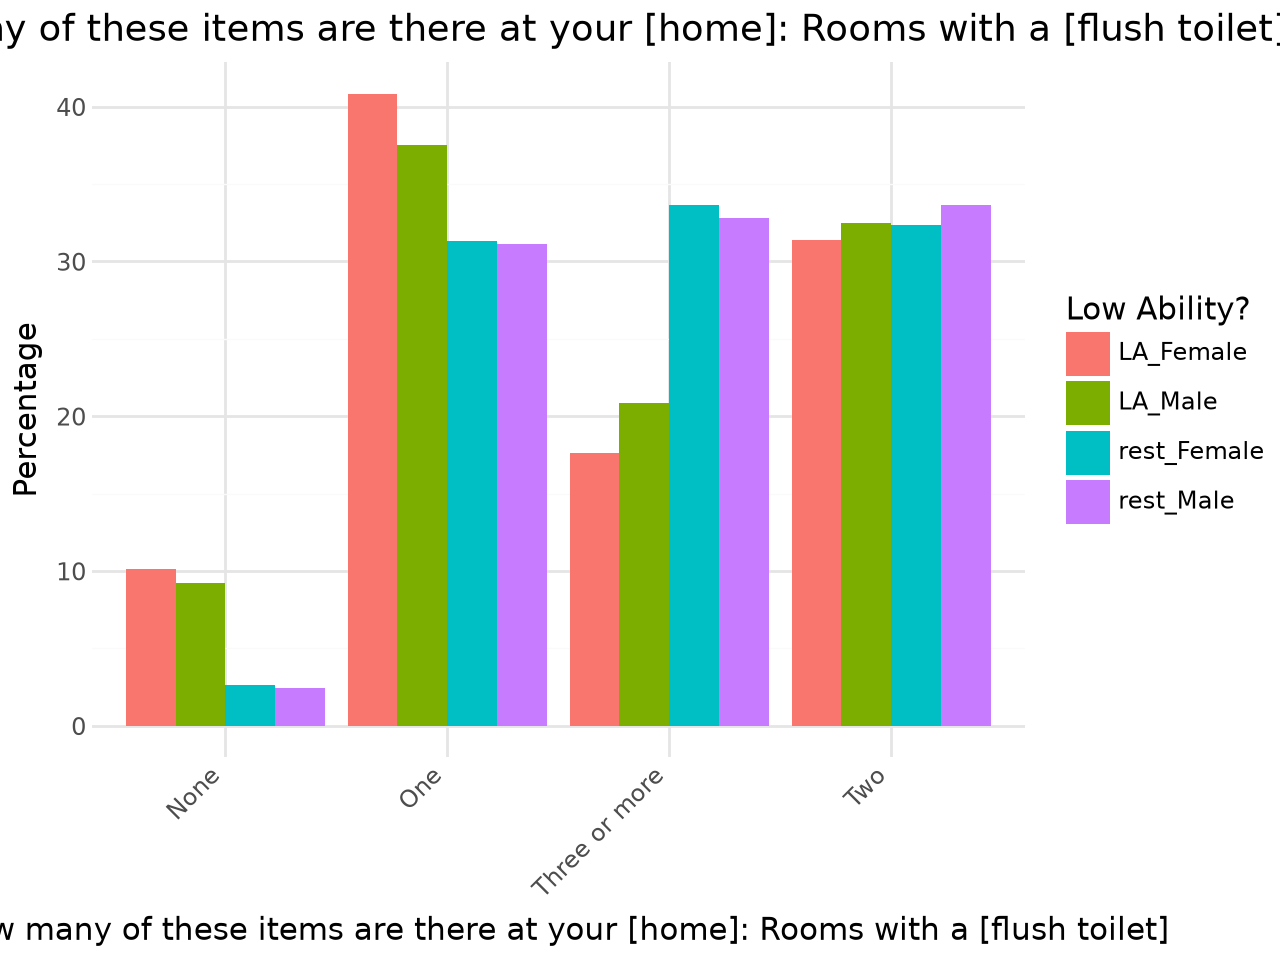

In [2]:
def plot_factor(factor: str, cnt: str | None = None) -> ggplot:
    """Plot how each gender-ability group answered a given factor.

    Pupils are split into deciles of mean performance within their gender, and
    those in the lowest decile are labelled low ability (`LA_`). The bars show
    what percentage of each group chose each answer, so a factor where the
    `LA_` bars sit apart from the `rest_` bars is one that distinguishes
    low-performing pupils.

    Args:
        factor: The variable to plot, e.g. "ST251Q04JA".
        cnt: Restrict to a single country, e.g. "United Kingdom". All
            countries if None.

    Returns:
        A ggplot object.
    """
    frame = df.select("CNT", GENDER, *PV_COLS, pl.col(factor)).filter(
        pl.col(factor).is_not_null()
    )
    if cnt is not None:
        frame = frame.filter(pl.col("CNT") == cnt)

    counts = percentage_by_group(with_gender_ability_group(frame), factor).to_pandas()
    counts[factor] = pd.Categorical(
        counts[factor],
        categories=sorted(counts[factor].dropna().unique()),
        ordered=True,
    )

    label = LABELS[factor]
    return (
        ggplot(counts, aes(x=factor, y="pct", fill="gender_ability_group"))
        + geom_col(position="dodge")
        + theme_minimal()
        + theme(axis_text_x=element_text(angle=45, hjust=1))
        + labs(title=label, x=label, y="Percentage", fill="Low Ability?")
    )


plot_factor("ST251Q04JA", cnt="United Kingdom")


In [3]:
# Factors worth stepping through. Every variable carrying a reviewer comment in
# data/Codebook.csv is in the subset, so any of them can be dropped in here.
CANDIDATES = [
    "ST261Q03JA",  # Missed school because I was pregnant
    "ST006Q01JA",  # Mother has a PhD
    "ST008Q01JA",  # Father has a PhD
    "ST261Q10JA",  # Missed school because I couldn't pay fees
    "ST261Q11JA",  # Missed school because of natural disasters
    "ST295Q01JA",  # Eat dinner
    "ST251Q03JA",  # Rooms with a bath or shower
    "ST251Q04JA",  # Flush toilet
    "ST230Q01JA",  # Siblings
    "ST016Q01NA",  # Slider bar, how you feel about life
    "ST296Q04JA",  # Hours of homework a day
    "ST272Q01JA",  # Quality of maths instruction
]

for candidate in CANDIDATES:
    print(f"{candidate}: {LABELS[candidate]}")


ST261Q03JA: Why miss school for 3+ months: I was pregnant.
ST006Q01JA: Does your mother have any of the following qualifications: [ISCED level 8]
ST008Q01JA: Does your father have any of the following qualifications: [ISCED level 8]
ST261Q10JA: Why miss school for 3+ months: I could not pay [school fees].
ST261Q11JA: Why miss school for 3+ months: School was closed because of a natural disaster (e.g. flood, earthquake).
ST295Q01JA: How many days/wk after school: Eat dinner
ST251Q03JA: How many of these items are there at your [home]: Rooms with a bath or shower
ST251Q04JA: How many of these items are there at your [home]: Rooms with a [flush toilet]
ST230Q01JA: How many siblings (including brothers, sisters, step-brothers, and step-sisters) do you have?
ST016Q01NA: Overall, how satisfied are you with your life as a whole these days?
ST296Q04JA: How much time spent on homework in: Total time for all homework in all subjects, including subjects not listed above
ST272Q01JA: On 1-10 scale,

phd_no_a_levels gender_ability_group      n        pct
     impossible          rest_Female   3826   1.772412
       possible            rest_Male 204526  96.974496
     impossible              LA_Male   3750  16.001707
     impossible            LA_Female   1862   7.763185
     impossible            rest_Male   6381   3.025504
       possible             excluded     57 100.000000
       possible            LA_Female  22123  92.236815
       possible          rest_Female 212038  98.227588
       possible              LA_Male  19685  83.998293


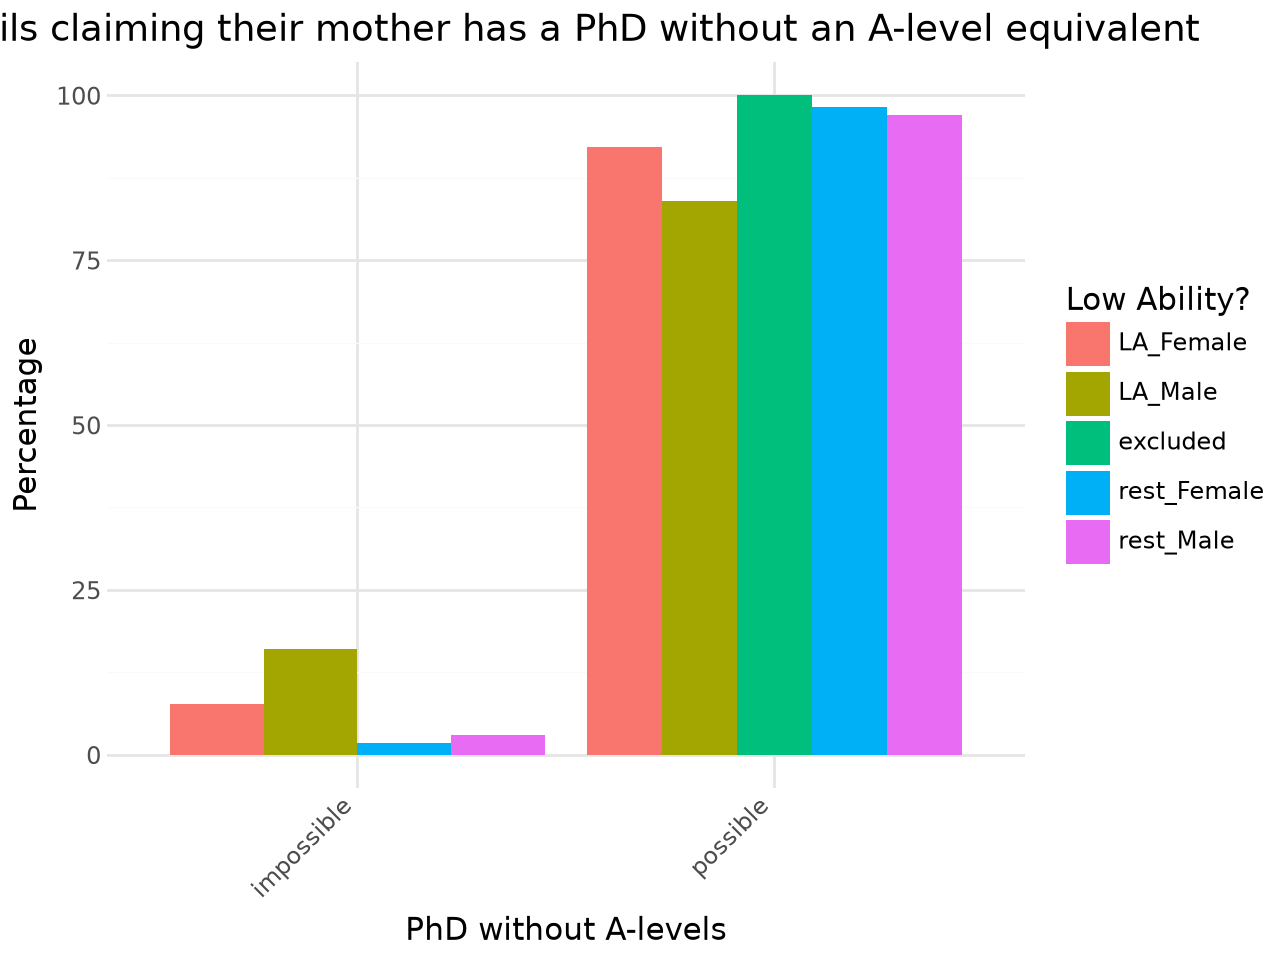

In [4]:
# A conjunction check: a mother cannot hold a PhD if she never completed upper
# secondary schooling. Pupils asserting both are answering inconsistently, and
# the question is whether that concentrates among low-performing pupils.
parents = df.select("CNT", GENDER, *PV_COLS, "ST005Q01JA", "ST006Q01JA").filter(
    pl.col("ST005Q01JA").is_not_null() & pl.col("ST006Q01JA").is_not_null()
)

impossible = (pl.col("ST005Q01JA") != pl.lit("<ISCED level 3.4>")) & (
    pl.col("ST006Q01JA") == pl.lit("Yes")
)
flagged = with_gender_ability_group(parents).with_columns(
    pl.when(impossible)
    .then(pl.lit("impossible"))
    .otherwise(pl.lit("possible"))
    .alias("phd_no_a_levels")
)

counts = percentage_by_group(flagged, "phd_no_a_levels").to_pandas()
print(counts.to_string(index=False))

(
    ggplot(counts, aes(x="phd_no_a_levels", y="pct", fill="gender_ability_group"))
    + geom_col(position="dodge")
    + theme_minimal()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + labs(
        title="Pupils claiming their mother has a PhD without an A-level equivalent",
        x="PhD without A-levels",
        y="Percentage",
        fill="Low Ability?",
    )
)
